##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 2

**Group name:** The Floppas

**Student names & numbers:**
* Miguel Brugge - 102093
* Gabriela Panayotova - 098931
* Svetlozara Kirova - 099153


---

## 0. Iteration setup

**Import libraries**

In [52]:
# CODE CELL: import the necessary libraries for this iteration
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Load and merge datasets**

In [53]:
# CODE CELL: import the necessary datasets for this iteration
# Make sure to load your cleaned dataset from Iteration 1 AND the new inspection data for Iteration 2.
# Merge them together based on the Ship_ID.
df_inventory = pd.read_csv('data/ships_inventory_iter1_out.csv')
df_inspections = pd.read_csv('data/ship_inspections_iter2.csv')

In [54]:
df_inventory.head()

,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector,mean_pred,median_pred
0,7316160254,4950,7505.0,Galactic Motors,Mon Cala Ocean Worlds,18312.138184,15590.0
1,7316115206,18999,7518.0,Galactic Motors,Thraxos Blockade,18312.138184,15590.0
2,7315865657,4000,7486.0,Republic Aerospace,Indoumodo Sector,18312.138184,15590.0
3,7314772431,6495,7511.0,Nebula Industries,Pantora Moon,18312.138184,15590.0
4,7311539325,3995,7499.0,Corellian Engineering,Malastare Narrows,18312.138184,15590.0


In [55]:
df_inspections.head()

,Ship_ID,Hull_Integrity,Reactor_Power,Propulsion_Type,Ship_Class
0,7316814884,Operational,80.0,Ion Drive,Hauler
1,7316814758,Operational,80.0,Hyperdrive,Hauler
2,7316814989,Pristine,80.0,Hyperdrive,Hauler
3,7316743432,Pristine,80.0,Plasma Thruster,Hauler
4,7316356412,Operational,60.0,Ion Drive,Freighter


We used left join because we need the data to be based on the inspections. Some ships may not have an inspection, so they do not need to be part of the dataset.

In [56]:
df = df_inspections.merge(df_inventory, left_on='Ship_ID', right_on='Ship_ID', how='left')
df.head()

,Ship_ID,Hull_Integrity,Reactor_Power,Propulsion_Type,Ship_Class,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector,mean_pred,median_pred
0,7316814884,Operational,80.0,Ion Drive,Hauler,33590.0,7514.0,General Mining Corp,Alderaan System,18312.138184,15590.0
1,7316814758,Operational,80.0,Hyperdrive,Hauler,22590.0,7510.0,Corellian Engineering,Alderaan System,18312.138184,15590.0
2,7316814989,Pristine,80.0,Hyperdrive,Hauler,39590.0,7520.0,Corellian Engineering,Alderaan System,18312.138184,15590.0
3,7316743432,Pristine,80.0,Plasma Thruster,Hauler,30990.0,7517.0,Kuat Drive Yards,Alderaan System,18312.138184,15590.0
4,7316356412,Operational,60.0,Ion Drive,Freighter,15000.0,7513.0,Galactic Motors,Alderaan System,18312.138184,15590.0


---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

**Situation description**

*Describe the problem surrounding the safety inspections. Why is the current process (human estimation/gut feeling) a risk?*

**Business objective(s)**

*Justify why a standardized, rule-based expert system is needed.*

**Data mining goal(s)**

*Explain what type of modeling task this is and why.*

**Success criteria**

*Determine success criteria for this iteration*

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Show the summary statistics and describe the new variables (e.g., Propulsion_Type, Reactor_Power, Hull_Integrity). Describe your findings.*

| Column          | Data Type | Interpretation                                                                   |
| --------------- | --------- | -------------------------------------------------------------------------------- |
| Ship_ID         | int64     | Key to link each ship to the inventory.                                          |
| Propulsion_Type | str       | Engine technology (e.g., Ion Drive, Solar Sail). Has missing values (NaN).       |
| Ship_Class      | str       | Type of ship (e.g., Cargo, Military, Exploration).                               |
| Reactor_Power   | float64   | Engine output in TeraWatts (TW). Has missing values and some very high outliers. |
| Hull_Integrity  | str       | Mechanic’s notes on ship condition. Used to evaluate the model.                  |


The dataset has 368,807 ships, which we saw from `df.info()`. Reactor_Power has missing values and its average is about 72 TW, with most ships between 40 and 80 TW, but the maximum is 360 TW, showing some very high numbers (`df.describe()`). Propulsion_Type also has missing values (`df.info()`). Hull_Integrity has no missing values and contains text notes from mechanics (`df.info()`).

In [57]:
# CODE CELL: Show basic statistics and information
df.dtypes

Ship_ID                int64
Hull_Integrity           str
Reactor_Power        float64
Propulsion_Type          str
Ship_Class               str
Galactic_Credits     float64
Model_Cycle          float64
Ship_Manufacturer        str
Sector                   str
mean_pred            float64
median_pred          float64
dtype: object

In [58]:
df.describe()

,Ship_ID,Reactor_Power,Galactic_Credits,Model_Cycle,mean_pred,median_pred
count,3.688070e+05,339340.000000,361561.000000,354295.000000,361561.000000,361561.0
mean,7.311485e+09,71.589586,18312.138184,7511.213046,18312.138184,15590.0
std,4.381111e+06,44.647300,12605.886645,8.926921,0.000000,0.0
min,7.301583e+09,30.000000,501.000000,7400.000000,18312.138184,15590.0
25%,7.308105e+09,40.000000,7800.000000,7508.000000,18312.138184,15590.0
50%,7.312604e+09,60.000000,15590.000000,7513.000000,18312.138184,15590.0
75%,7.315245e+09,80.000000,26995.000000,7517.000000,18312.138184,15590.0
max,7.317101e+09,360.000000,58000.000000,7522.000000,18312.138184,15590.0


In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 368807 entries, 0 to 368806
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Ship_ID            368807 non-null  int64  
 1   Hull_Integrity     368807 non-null  str    
 2   Reactor_Power      339340 non-null  float64
 3   Propulsion_Type    312103 non-null  str    
 4   Ship_Class         368807 non-null  str    
 5   Galactic_Credits   361561 non-null  float64
 6   Model_Cycle        354295 non-null  float64
 7   Ship_Manufacturer  361561 non-null  str    
 8   Sector             361561 non-null  str    
 9   mean_pred          361561 non-null  float64
 10  median_pred        361561 non-null  float64
dtypes: float64(5), int64(1), str(5)
memory usage: 31.0 MB


**Visualizations and patterns**

*Discover patterns in the data that will help you determine the inspection rules. Create visualizations that show the relationship between variables like Reactor_Power, Propulsion_Type, Ship_Class on one side, and the target variable Hull_Integrity on the other. Describe any hard rules you discover (e.g., relationships with dangerous reactors or advanced tech).*

Looking at the plots, we can see some clear patterns. Ships with very high Reactor_Power (above 150 TW) often have Critical hulls, while ships with lower power are usually Operational or Pristine.

Certain propulsion types, like Ion Drive and Hyperdrive, have more ships with Critical hulls, meaning these engines may need closer inspection.

Some ship classes, such as Shuttles, are more likely to have damaged hulls, while smaller ships like Troop Transport and Speedsters tend to stay in better condition. 

Overall, high reactor power, advanced propulsion, and larger ship classes are linked to higher risk of Critical hulls.

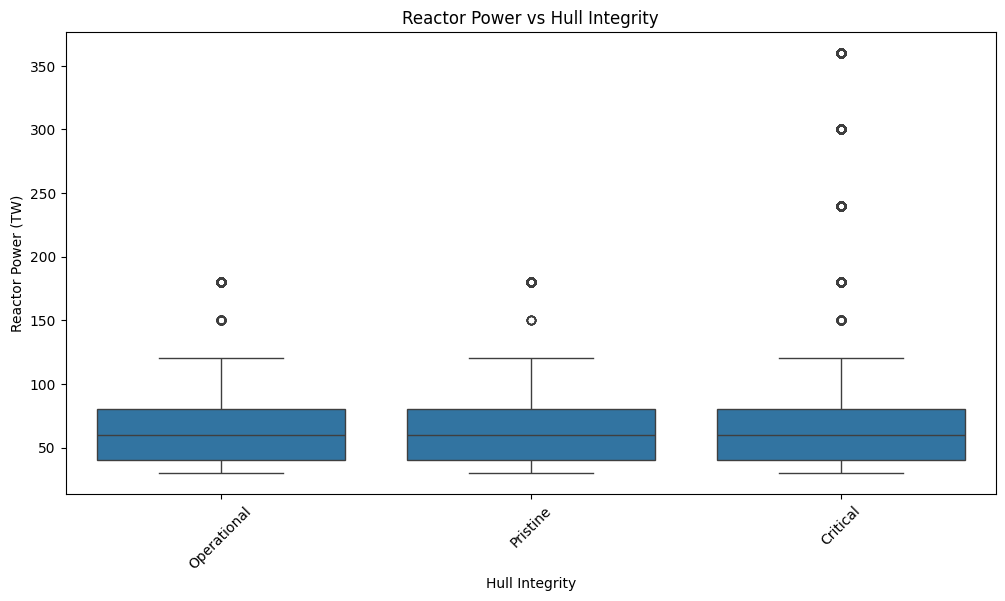

In [60]:
# CODE CELL: Generate visualizations (e.g., bar charts, boxplots comparing features against Hull_Integrity)

# Reactor_Power vs Hull_Integrity
plt.figure(figsize=(12,6))
sns.boxplot(x='Hull_Integrity', y='Reactor_Power', data=df)
plt.title('Reactor Power vs Hull Integrity')
plt.xticks(rotation=45)
plt.ylabel('Reactor Power (TW)')
plt.xlabel('Hull Integrity')
plt.show()

<Figure size 1200x600 with 0 Axes>

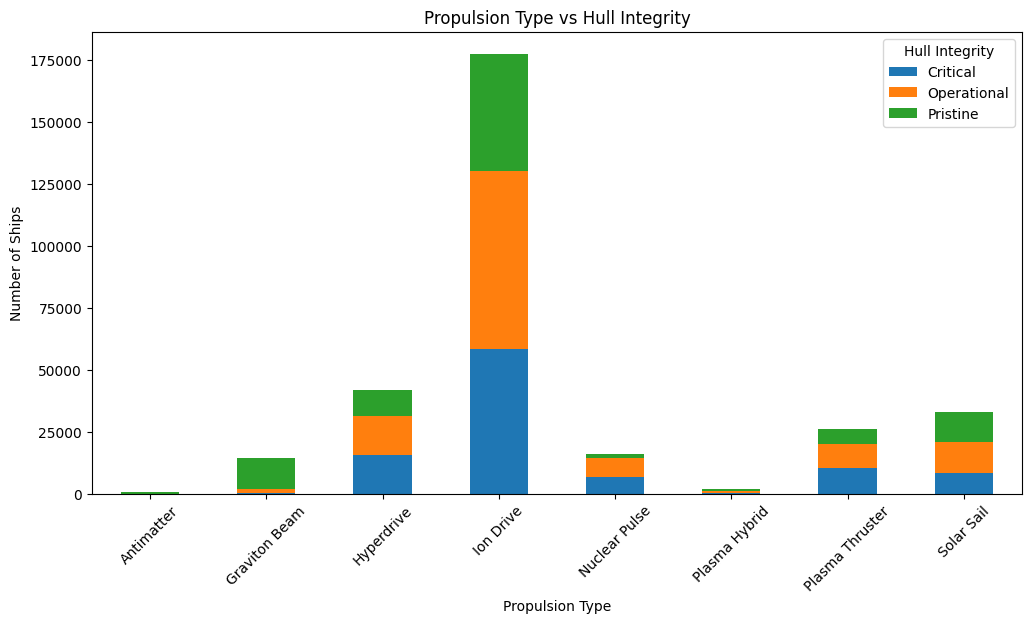

In [61]:
# Propulsion_Type vs Hull_Integrity
plt.figure(figsize=(12,6))
prop_counts = pd.crosstab(df['Propulsion_Type'], df['Hull_Integrity'])
prop_counts.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Propulsion Type vs Hull Integrity')
plt.ylabel('Number of Ships')
plt.xlabel('Propulsion Type')
plt.xticks(rotation=45)
plt.legend(title='Hull Integrity')
plt.show()

<Figure size 1000x600 with 0 Axes>

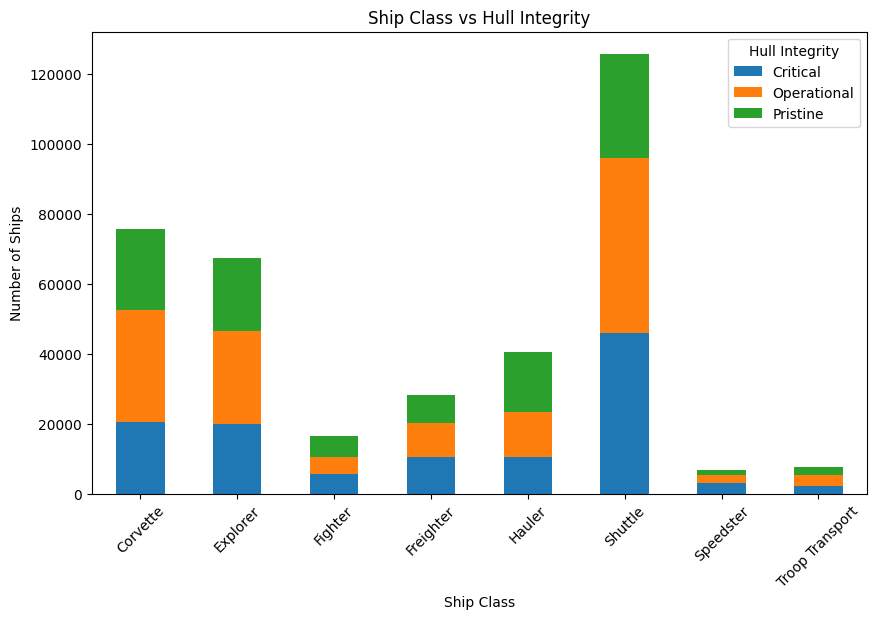

In [62]:
# Ship_Class vs Hull_Integrity
plt.figure(figsize=(10,6))
ship_counts = pd.crosstab(df['Ship_Class'], df['Hull_Integrity'])
ship_counts.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Ship Class vs Hull Integrity')
plt.ylabel('Number of Ships')
plt.xlabel('Ship Class')
plt.xticks(rotation=45)
plt.legend(title='Hull Integrity')
plt.show()

**Data insights and data quality**
* **Insights:** What clear rules/patterns did you find that we can use for classification later?
* **Quality issues:** Document missing values (specifically in Propulsion and Reactor) and outliers.

**Insights:**
- If Reactor_Power > 150 TW → High probability of Critical hull
- If Propulsion_Type is Ion Drive or Hyperdrive → Increased risk of Critical hull
- If Ship_Class is Shuttle or Corvette → More likely Damaged or Critical
- If Ship_Class is Troop Transport or Speedster → More likely Operational or Pristine
- Combination rule: High Reactor_Power + Advanced Propulsion + Large Ship_Class → Highest risk of Critical classification

**Quality issues:**
- Missing values, especially in Propulsion and Reactor
- Outliers, like extremely high reactor power

---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**
*Describe and justify how you resolve the missing values.*

In [ ]:
# CODE CELL: Data cleaning, preprocessing


**Adjusting dataset (optional)**
*If you adjusted the dataset for modeling in additional ways, describe that here*

In [64]:
# OPTIONAL CODE CELL: Additional preprocessing steps

---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
*Build a manual classifier. Use the insights from step 2 to write a Python function with if/elif/else statements that predicts the Hull_Condition for each ship. Apply this function to your dataset and save the predictions in a new column.*

In [65]:
# CODE CELL: Model training and setup code

**Testing and performance**
*Evaluate your manual rules. Calculate the metrics and generate a **confusion matrix** (visualize this using seaborn/matplotlib).*

In [66]:
# CODE CELL: Model evaluation code

---

## 5. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives)*

**Assessment against succes criteria** 
*How well does your manual model identify 'Critical' or 'Pristine' ships? Did you meet the goals set in the Business Understanding?*

**Key findings and limitations**
*What are the limitations of a manual, hard-rule-based system? Why might a machine Learning model be better in the next iteration?*

Use [pandas' to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) to export your cleaned and merged dataset for the next iteration. 

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Student name 1 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 2 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 3 | *Contribution description* | *Personal lessons learned this iteration* |